# Facial Expression Classification — FER-2013
## Model 1: ResNet50V2 Transfer Learning with Image Augmentation

In [1]:
# Install kaggle if not already installed
!pip install kaggle -q

In [2]:
# ── Core imports ──────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50V2
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.models import Sequential, Model
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.layers import *
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ── Kaggle authentication ──────────────────────────────────────
# Upload your kaggle.json first via Files panel on the left
os.makedirs('/root/.kaggle', exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json
print('Kaggle API key configured.')

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Kaggle API key configured.


In [4]:
# ── Download and unzip FER-2013 dataset ───────────────────────
!kaggle datasets download -d msambare/fer2013 --force
!unzip -o fer2013.zip -d fer2013_data
print('Dataset ready.')

Streaming output truncated to the last 5000 lines.
  inflating: fer2013_data/train/sad/Training_65267116.jpg  
  inflating: fer2013_data/train/sad/Training_65275626.jpg  
  inflating: fer2013_data/train/sad/Training_6529266.jpg  
  inflating: fer2013_data/train/sad/Training_65329617.jpg  
  inflating: fer2013_data/train/sad/Training_65338712.jpg  
  inflating: fer2013_data/train/sad/Training_65338797.jpg  
  inflating: fer2013_data/train/sad/Training_65387162.jpg  
  inflating: fer2013_data/train/sad/Training_65404494.jpg  
  inflating: fer2013_data/train/sad/Training_65426218.jpg  
  inflating: fer2013_data/train/sad/Training_65430136.jpg  
  inflating: fer2013_data/train/sad/Training_65437377.jpg  
  inflating: fer2013_data/train/sad/Training_6545735.jpg  
  inflating: fer2013_data/train/sad/Training_65463385.jpg  
  inflating: fer2013_data/train/sad/Training_65473985.jpg  
  inflating: fer2013_data/train/sad/Training_65502829.jpg  
  inflating: fer2013_data/train/sad/Training_655053

In [5]:
# ── Directory paths ────────────────────────────────────────────
train_dir = 'fer2013_data/train'
test_dir  = 'fer2013_data/test'

# Check class folders exist
print('Train classes:', os.listdir(train_dir))
print('Test  classes:', os.listdir(test_dir))

Train classes: ['angry', 'sad', 'surprise', 'disgust', 'happy', 'fear', 'neutral']
Test  classes: ['angry', 'sad', 'surprise', 'disgust', 'happy', 'fear', 'neutral']


## Image Transformations — Rationale

FER-2013 contains 48x48 grayscale face images. The following augmentations were chosen carefully:

| Transformation | Reason |
|---|---|
| **Horizontal flip** | Faces look the same mirrored — valid augmentation |
| **Rotation (±15°)** | Accounts for natural head tilts in real photos |
| **Zoom (±10%)** | Faces appear at different distances from camera |
| **Width/Height shift (±10%)** | Face may not be perfectly centred |
| **Brightness adjustment** | Different lighting conditions in real environments |
| **Rescale 1/255** | Normalises pixel values to [0, 1] range |

**Transformations deliberately avoided:**
- Vertical flip — upside-down faces are not realistic
- Heavy shear/distortion — would destroy facial expression features
- Channel shift — not applicable for grayscale images

**Note:** ResNet50V2 requires RGB input (3 channels) and minimum 32x32 size.
We resize images to 224x224 and convert grayscale to RGB by repeating channels.

In [39]:
# ── Configuration ──────────────────────────────────────────────
IMG_SIZE    = (160, 160)
BATCH_SIZE  = 64
NUM_CLASSES = 7
EPOCHS_UNFROZEN = 35
EPOCHS_FROZEN = 30

In [40]:
# ── Data Loaders (The Modern tf.data Way) ──────────────────────
print('Loading datasets...')

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)
class_names = train_ds.class_names

Loading datasets...
Found 28709 files belonging to 7 classes.
Using 22968 files for training.
Found 28709 files belonging to 7 classes.
Using 5741 files for validation.
Found 7178 files belonging to 7 classes.


In [41]:
print("Computing class weights...")
y_labels = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in train_ds], axis=0)

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_labels),
    y=y_labels
)
class_weights = dict(enumerate(class_weights_array))
print("Class Weights:", class_weights)

Computing class weights...
Class Weights: {0: np.float64(1.0196217703986505), 1: np.float64(9.03896103896104), 2: np.float64(0.998825831702544), 3: np.float64(0.5644491410877098), 4: np.float64(0.8275265717888669), 5: np.float64(0.8558014755197854), 6: np.float64(1.3177280550774526)}


In [42]:
AUTOTUNE = tf.data.AUTOTUNE

# Prefetch prepares the next batch on the CPU while the GPU is training
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

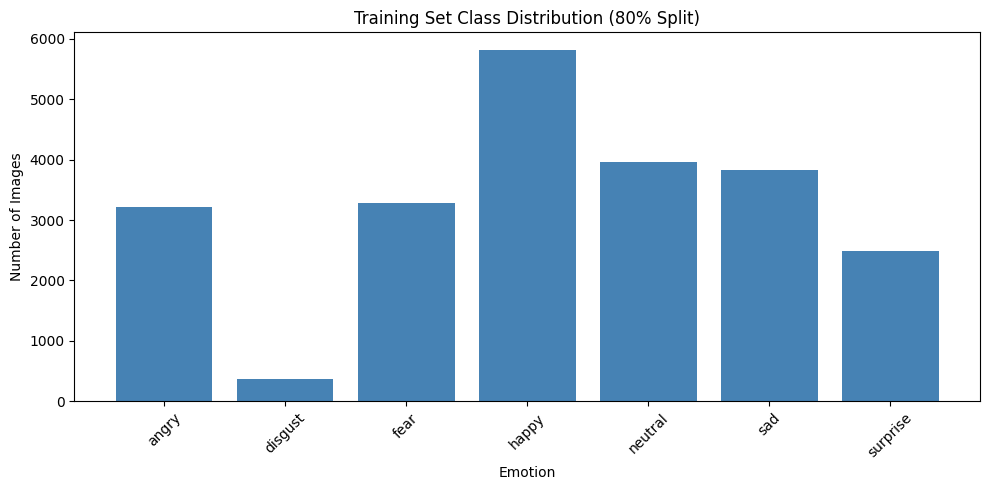

Class distribution: {'angry': np.int64(3218), 'disgust': np.int64(363), 'fear': np.int64(3285), 'happy': np.int64(5813), 'neutral': np.int64(3965), 'sad': np.int64(3834), 'surprise': np.int64(2490)}


In [43]:
# We already extracted y_labels earlier when calculating class weights!
unique_classes, counts = np.unique(y_labels, return_counts=True)
class_counts = dict(zip(class_names, counts))

plt.figure(figsize=(10, 5))
plt.bar(class_counts.keys(), class_counts.values(), color='steelblue')
plt.title('Training Set Class Distribution (80% Split)')
plt.xlabel('Emotion')
plt.ylabel('Number of Images')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print('Class distribution:', class_counts)

## ResNet50V2 Transfer Learning — Architecture

**Why transfer learning?**
ResNet50V2 was pre-trained on ImageNet (1.2 million images, 1000 classes).
Its early layers already detect edges, textures, and shapes — features also
useful for facial expression recognition. We fine-tune it for our 7-class task.

**Two-stage training strategy:**
1. **Stage 1 — Frozen base:** Train only the new classification head. The ResNet weights stay fixed. This prevents the pre-trained features from being destroyed early on.
2. **Stage 2 — Fine-tuning:** Unfreeze the top layers of ResNet and train the whole network at a very low learning rate to gently adapt the features to facial expressions.

In [47]:
# ── On-GPU Data Augmentation ───────────────────────────────────
data_augmentation = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.028, fill_mode='nearest'),
    layers.RandomZoom(height_factor=0.2, width_factor=0.2, fill_mode='nearest'),
    layers.RandomTranslation(height_factor=0.1, width_factor=0.1, fill_mode='nearest'),
    # layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="gpu_augmentation")


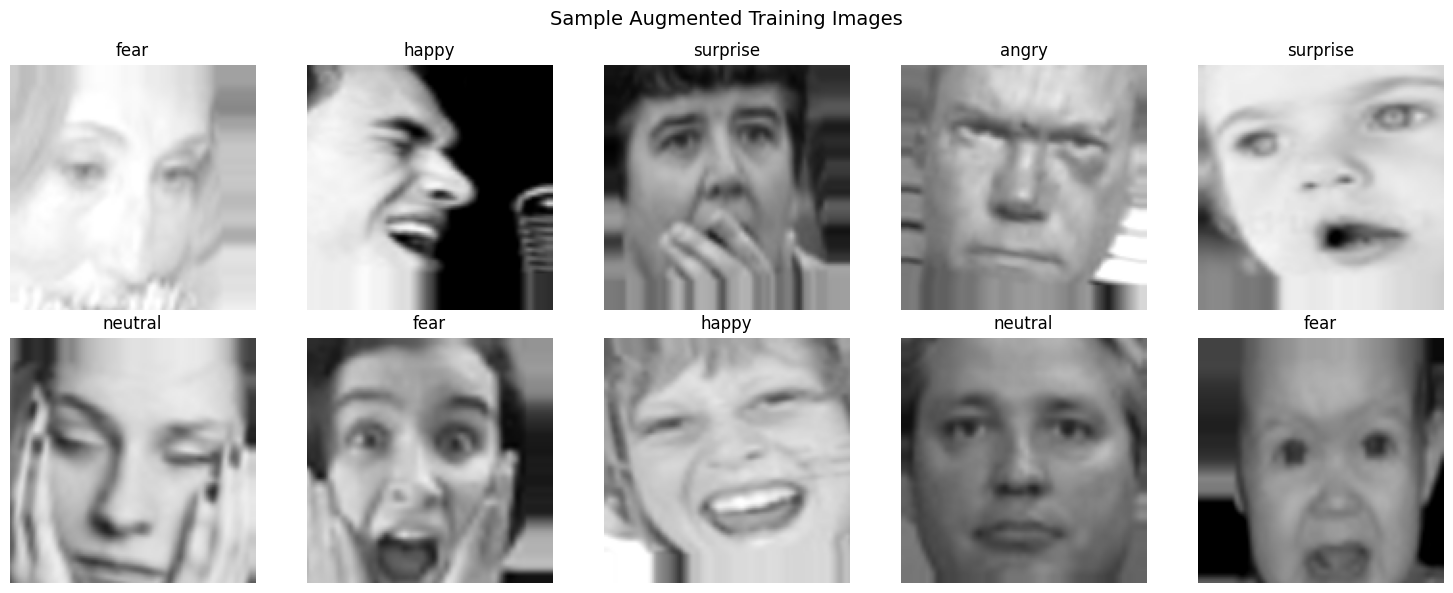

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab one batch of images and labels from the tf.data dataset
sample_images, sample_labels = next(iter(train_ds))

# 2. Apply our standalone augmentation layer to see what the model actually sees
# (training=True tells the layers to actively apply random flips/rotations)
augmented_images = data_augmentation(sample_images, training=True)

fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Augmented Training Images', fontsize=14)

for i, ax in enumerate(axes.flat):
    # Convert tensor to numpy and cast to uint8 so matplotlib displays it correctly
    img = augmented_images[i].numpy().astype("uint8")
    ax.imshow(img)
    label_idx = np.argmax(sample_labels[i])
    ax.set_title(class_names[label_idx])
    ax.axis('off')

plt.tight_layout()
plt.show()

In [48]:
# ── Build ResNet50V2 Transfer Learning Model ───────────────────

def build_resnet_model(input_shape=(160, 160, 3), num_classes=7):
    # Load pre-trained ResNet50V2
    base_model = ResNet50V2(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # STAGE 1: Freeze all base model layers entirely
    base_model.trainable = False
    print(f'Base model layers: {len(base_model.layers)}')
    print(f'Trainable layers (frozen): {len([l for l in base_model.layers if l.trainable])}')

    # Build the full model using Functional API
    inputs = tf.keras.Input(shape=input_shape)

    # 1. Apply GPU Augmentation first
    x = data_augmentation(inputs)

    # 2. Pass through ResNet50V2 base
    # training=False is CRITICAL here so BatchNorm layers don't update their statistics
    x = base_model(x, training=False)

    # 3. Custom Classification Head (Your original architecture)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs, name='ResNet50V2_FER')
    return model, base_model

resnet_model, base_model = build_resnet_model(
    input_shape=IMG_SIZE + (3,),
    num_classes=NUM_CLASSES
)

resnet_model.summary()

Base model layers: 190
Trainable layers (frozen): 0


Model: "ResNet50V2_FER"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_26 (InputLayer)     │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gpu_augmentation (Sequential)   │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50v2 (Functional)         │ (None, 5, 5, 2048)     │    23,564,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_7      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,123,143 (92.02 MB)

 Trainable params: 558,343 (2.13 MB)

 Non-trainable params: 23,564,800 (89.89 MB)

In [49]:
# ── Stage 1: Train classification head only (base frozen) ─────

resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_stage1 = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
]

print('Stage 1: Training classification head (base frozen)...')
history_stage1 = resnet_model.fit(
    train_ds,                  # Using tf.data dataset!
    validation_data=val_ds,    # Using tf.data dataset!
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks_stage1,
    class_weight=class_weights,
    verbose=1
)
print('Stage 1 complete.')

Stage 1: Training classification head (base frozen)...
Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 47s 105ms/step - accuracy: 0.2885 - loss: 1.8338 - val_accuracy: 0.3809 - val_loss: 1.6260 - learning_rate: 0.0010
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step - accuracy: 0.3373 - loss: 1.7011 - val_accuracy: 0.4006 - val_loss: 1.6027 - learning_rate: 0.0010
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 39s 109ms/step - accuracy: 0.3547 - loss: 1.6481 - val_accuracy: 0.4189 - val_loss: 1.5488 - learning_rate: 0.0010
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 36s 99ms/step - accuracy: 0.3753 - loss: 1.6115 - val_accuracy: 0.4360 - val_loss: 1.4980 - learning_rate: 0.0010
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.3907 - loss: 1.5781 - val_accuracy: 0.4435 - val_loss: 1.4927 - learning_rate: 0.0010
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 35s 98ms/step - accuracy: 0.3884 - loss: 1.5703 - val_accuracy: 0.4367 - val_loss: 1.4815 - learning_rate: 0.0010
Epoch 7/30
359/359 

In [50]:
from google.colab import drive
import os

drive.mount('/content/drive')

# Define checkpoint directory
CHECKPOINT_DIR = '/content/drive/MyDrive/checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f'Checkpoint directory created at: {CHECKPOINT_DIR}')
# Save model after Stage 1
stage1_checkpoint_path = os.path.join(
    CHECKPOINT_DIR,
    'resnet50v2_stage1.weights.h5'
)

resnet_model.save_weights(stage1_checkpoint_path)

print(f'Stage 1 weights saved to: {stage1_checkpoint_path}')

Mounted at /content/drive
Checkpoint directory created at: /content/drive/MyDrive/checkpoints
Stage 1 weights saved to: /content/drive/MyDrive/checkpoints/resnet50v2_stage1.weights.h5


In [51]:
base_model.trainable = True

# Freeze bottom layers, keep top 30 unfrozen
fine_tune_from = len(base_model.layers) - 50
for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False

# CRITICAL: Re-freeze all BatchNorm layers
# If BatchNorm updates during fine-tuning, it ruins the learned representations
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = len([l for l in base_model.layers if l.trainable])
print(f'Fine-tuning top {trainable_count} layers of ResNet50V2')

# Recompile with a much lower learning rate
resnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_callback = ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'resnet50v2_stage2_best.weights.h5'),
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

callbacks_stage2 = [
    EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=0.00005, verbose=1),
    checkpoint_callback
]

print('Stage 2: Fine-tuning top layers...')
history_stage2 = resnet_model.fit(
    train_ds,                  # Using tf.data dataset!
    validation_data=val_ds,    # Using tf.data dataset!
    epochs=EPOCHS_UNFROZEN,
    callbacks=callbacks_stage2,
    verbose=1,
    class_weight=class_weights
)

print('Stage 2 complete.')

Fine-tuning top 22 layers of ResNet50V2
Stage 2: Fine-tuning top layers...
Epoch 1/35
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step - accuracy: 0.4826 - loss: 1.3203
Epoch 1: val_loss improved from None to 1.27291, saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5

Epoch 1: finished saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 66s 150ms/step - accuracy: 0.4888 - loss: 1.2992 - val_accuracy: 0.5158 - val_loss: 1.2729 - learning_rate: 1.0000e-05
Epoch 2/35
359/359 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step - accuracy: 0.5047 - loss: 1.2621
Epoch 2: val_loss improved from 1.27291 to 1.25022, saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5

Epoch 2: finished saving model to /content/drive/MyDrive/checkpoints/resnet50v2_stage2_best.weights.h5
359/359 ━━━━━━━━━━━━━━━━━━━━ 49s 136ms/step - accuracy: 0.5039 - loss: 1.2610 - val_accuracy: 0.5290 - val_loss: 1.2502 - l

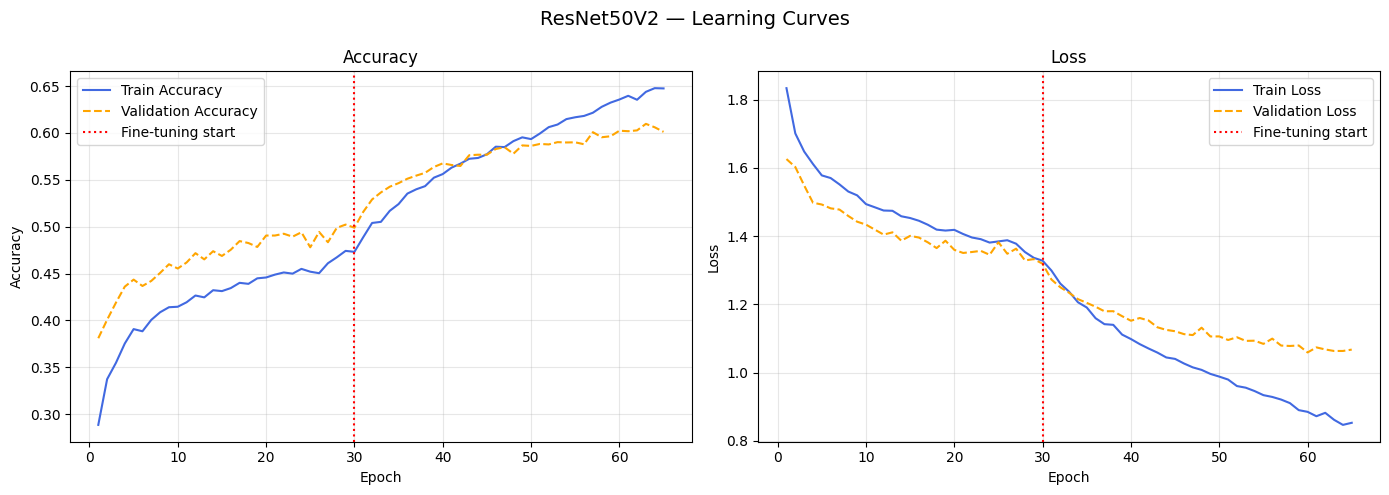

In [52]:
# ── Plot Learning Curves (both stages combined) ────────────────

def plot_learning_curves(history1, history2, title_prefix='ResNet50V2'):
    """
    Combines training history from both stages and plots
    accuracy and loss learning curves.
    """
    # Combine both stages
    acc     = history1.history['accuracy']     + history2.history['accuracy']
    val_acc = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss    = history1.history['loss']         + history2.history['loss']
    val_loss= history1.history['val_loss']     + history2.history['val_loss']

    stage_boundary = len(history1.history['accuracy'])
    epochs_range = range(1, len(acc) + 1)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title_prefix} — Learning Curves', fontsize=14)

    # Accuracy plot
    ax1.plot(epochs_range, acc,     label='Train Accuracy',      color='royalblue')
    ax1.plot(epochs_range, val_acc, label='Validation Accuracy', color='orange', linestyle='--')
    ax1.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)

    # Loss plot
    ax2.plot(epochs_range, loss,     label='Train Loss',      color='royalblue')
    ax2.plot(epochs_range, val_loss, label='Validation Loss', color='orange', linestyle='--')
    ax2.axvline(x=stage_boundary, color='red', linestyle=':', label='Fine-tuning start')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_learning_curves(history_stage1, history_stage2, 'ResNet50V2')

In [53]:
# ── Evaluate on Test Set ───────────────────────────────────────

print('Evaluating ResNet50V2 on test set...')
test_loss, test_acc = resnet_model.evaluate(test_ds, verbose=1)
print(f'\nTest Loss:     {test_loss:.4f}')
print(f'Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')

Evaluating ResNet50V2 on test set...
113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 71ms/step - accuracy: 0.6138 - loss: 1.0525

Test Loss:     1.0525
Test Accuracy: 0.6138 (61.38%)


In [56]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print('Generating predictions...')
# 1. Predict directly on the dataset
y_pred_probs = resnet_model.predict(test_ds, verbose=1)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Extract true labels from the tf.data pipeline
# We iterate through the test dataset, grab the labels (y), and find the max index
y_true = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in test_ds], axis=0)

print('\nClassification Report:')
print(classification_report(
    y_true,
    y_pred_classes,
    target_names=class_names
))

Generating predictions...
113/113 ━━━━━━━━━━━━━━━━━━━━ 9s 75ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.51      0.52      0.52       958
     disgust       0.60      0.63      0.62       111
        fear       0.54      0.32      0.40      1024
       happy       0.81      0.83      0.82      1774
     neutral       0.55      0.62      0.58      1233
         sad       0.47      0.49      0.48      1247
    surprise       0.68      0.80      0.73       831

    accuracy                           0.61      7178
   macro avg       0.60      0.60      0.59      7178
weighted avg       0.61      0.61      0.61      7178



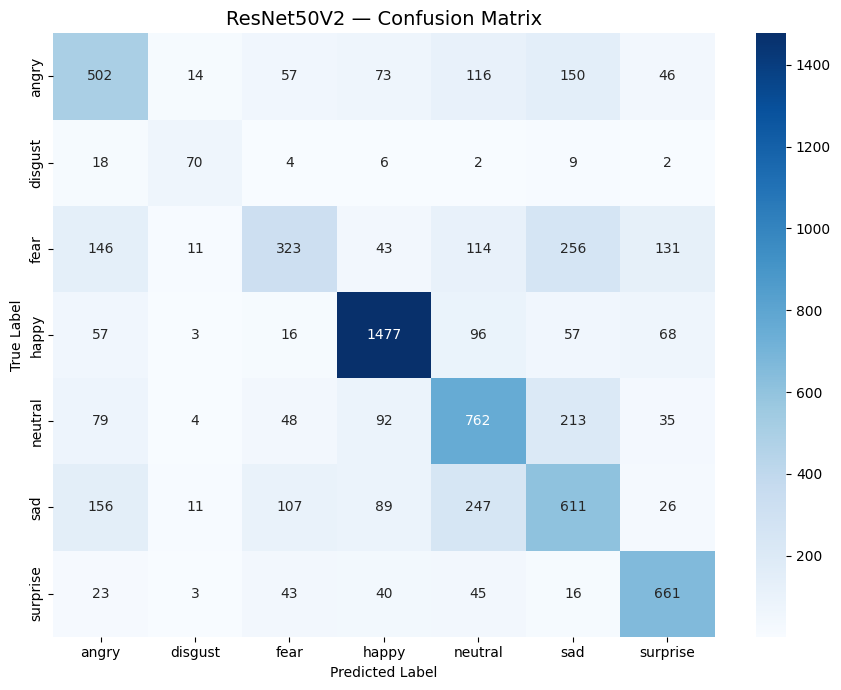

Confusion matrix displayed.


In [57]:
# ── Confusion Matrix ───────────────────────────────────────────

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title('ResNet50V2 — Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.show()

print('Confusion matrix displayed.')

In [58]:
# ── Save the model for reuse ───────────────────────────────────
resnet_model.save('resnet50v2_fer2013.h5')
print('Model saved as resnet50v2_fer2013.h5')

Model saved as resnet50v2_fer2013.h5


In [59]:
resnet_model.save('my_model.keras')